### Assess Recovery

We fit a bunch of injected events, or at least those that passed our event and anomaly detection pipeline. Let's assess how well we did in 1) detection and 2) classification. 

#### Detection Recovery

In [1]:
# system imports
import os
import time
import sys
import glob
from tqdm import tqdm
#from pathlib import Path

# data access imports
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# display imports
from IPython.display import HTML

# multiprocessing imports
import multiprocessing as mp
from multiprocessing.pool import ThreadPool

# data challenge imports
#import MulensModel
import emcee
#from pyLIMA.pyLIMASS import SourceLensProbabilities
import RTModel

# data analysis/visualization imports
import numpy as np
import matplotlib.pyplot as plt

#### IMPORTANT: Who are you? 

In [2]:
event_data_me = 'event_data_chris/' # please change 'chris' to your name, otherwise you will overwrite my work

#### Mise en place

In [3]:
TIER = "Beginner" # change to Experienced or ML if you want to not be a baby
root_dir = '/home/mldc-ipacpeople-admin/teams/mldc-ipacpeople/'
events_dir = root_dir + event_data_me

In [4]:
def read_nature_txt(filename, n_chisquares):
    """
    Read Nature.txt if it's not empty and grab the top n_chisquares models. 
    """
    found = False
    n = 0
    chisqs = []
    model_files = []
    with open(filename, "r") as file:
        for line in file:
            # don't do anything until the chisquare line, which is where FinalModels are listed
            if 'chisquare' in line:
                found = True 
                continue # skip to next line, our search for the chisquare line is done
            
            # only then do we start processing lines
            if found == True:
                #print(line.strip())  # strip() removes trailing newlines

                # grab best N chisquares
                if n < n_chisquares:
                    chisq = line.split()[0]
                    model_file = line.split()[1]
                    chisqs.append(chisq)
                    model_files.append(model_file)
                else: 
                    continue
    
                n += 1
    file.close() 

    return chisqs, model_files

What fraction of favored models are planetary events? Of these, what are "contested" (either LS or BS is also among the favored models for that event)? 

In [12]:
if TIER == "Beginner":
    assess_range = np.arange(1,189)
elif TIER == "Experienced":
    assess_range = np.arange(189,2289)

n_chisquares = 1 # how many of the best chisquares to take
count_ls_list = []
count_bs_list = []
count_ps_list = []
for i in tqdm(assess_range[:38]): # need to re-run all events, but especially 1-38
    if int(i) < 1000:
        event_dir = events_dir + 'event_000' + "{:03d}/".format(i)
    elif 1000 <= int(i) < 10000:
        event_dir = events_dir + 'event_00' + "{:04d}/".format(i)
    event_final_models = glob.glob(event_dir+'FinalModels/*')

    # if there are no FinalModels (ie., if either there was no detection or there was no 
    if len(event_final_models)==0:
        count_ps_list.append(0)
        count_ls_list.append(0)
        count_bs_list.append(0)
        continue
    else:
        chisqs, model_filenames = read_nature_txt(event_dir+'Nature.txt', n_chisquares=len(event_final_models))

    # read N best model_filenames to get inferred parameters
    count_ls = 0
    count_bs = 0
    count_ps = 0
    #for j in range(n_chisquares):
    for j in range(len(event_final_models)): 
        chisq_temp = chisqs[j]
        model_filename_temp = model_filenames[j]
        # 1) how many events have LS, LX, or LO in FinalModels/?
        if (model_filename_temp[:2] == 'LS') or (model_filename_temp[:2] == 'LX') or (model_filename_temp[:2] == 'LO'):
            count_ls += 1
        if (model_filename_temp[:2] == 'BS') or (model_filename_temp[:2] == 'BO'):
            count_bs += 1
        if (model_filename_temp[:2] == 'PS') or (model_filename_temp[:2] == 'PX'):
            count_ps += 1

    count_ls_list.append(count_ls)
    count_bs_list.append(count_bs)
    count_ps_list.append(count_ps)
            
final_models_df = pd.DataFrame({'event': np.arange(1,39), 'PS': count_ps_list, 'LS': count_ls_list, 'BS': count_bs_list})       
        
        

100%|██████████| 38/38 [00:00<00:00, 308.97it/s]


In [13]:
final_models_df

,event,PS,LS,BS
0,1,0,3,0
1,2,0,4,1
2,3,0,1,0
3,4,1,0,0
4,5,0,10,0
5,6,0,1,0
6,7,0,1,1
7,8,0,1,0
8,9,0,2,1
9,10,0,5,1


In [14]:
# how many of each archetype?
print(final_models_df)
final_models_none = final_models_df.loc[(final_models_df['PS']==0)&(final_models_df['LS']==0)&(final_models_df['BS']==0)]
final_models_ps = final_models_df.loc[final_models_df['PS']>0]
final_models_ls = final_models_df.loc[final_models_df['LS']>0]
final_models_bs = final_models_df.loc[final_models_df['BS']>0]

print("fraction w/o good model: ", len(final_models_none)/len(final_models_df))
print("fraction with PS: ", len(final_models_ps)/len(final_models_df))
print("fraction with LS: ", len(final_models_ls)/len(final_models_df))
print("fraction with BS: ", len(final_models_bs)/len(final_models_df))

final_models_ls_only = final_models_ls.loc[(final_models_ls['PS']==0)&(final_models_ls['BS']==0)]
print("fraction with LS, unambiguously: ", len(final_models_ls_only)/len(final_models_df))


    event  PS  LS  BS
0       1   0   3   0
1       2   0   4   1
2       3   0   1   0
3       4   1   0   0
4       5   0  10   0
5       6   0   1   0
6       7   0   1   1
7       8   0   1   0
8       9   0   2   1
9      10   0   5   1
10     11   0   1   1
11     12   0   1   0
12     13   0   1   0
13     14   0   1   0
14     15   0   1   0
15     16   0   1   0
16     17   0   2   0
17     18   0   1   1
18     19   0   7   1
19     20   0   3   0
20     21   0   1   0
21     22   0   5   1
22     23   0   4   1
23     24   0   2   0
24     25   0   1   1
25     26   0   1   0
26     27   0   1   0
27     28   0   2   0
28     29   0   1   0
29     30   0   1   0
30     31   0   0   0
31     32   1   0   0
32     33   1   0   0
33     34   2   0   0
34     35   1   0   0
35     36   1   0   0
36     37   1   0   0
37     38   1   0   0
fraction w/o good model:  0.02631578947368421
fraction with PS:  0.21052631578947367
fraction with LS:  0.7631578947368421
fraction with BS:  

In [5]:
if TIER == "Beginner":
    assess_range = np.arange(1,189)
elif TIER == "Experienced":
    assess_range = np.arange(189,2289)
n_chisquares = 1 # how many of the best chisquares to take
s_list, q_list, u0_list, alpha_list, rho_list, tE_list, t0_list = [], [], [], [], [], [], []
s_err_list, q_err_list, u0_err_list, alpha_err_list, rho_err_list, tE_err_list, t0_err_list = [], [], [], [], [], [], []
event_list, chisq_list = [], []
back_flux1_list, source_flux1_list, back_flux2_list, source_flux2_list, back_flux3_list, source_flux3_list = [], [], [], [], [], []

for i in tqdm(assess_range):
    if int(i) < 1000:
        event_dir = events_dir + 'event_000' + "{:03d}/".format(i)
    elif 1000 <= int(i) < 10000:
        event_dir = events_dir + 'event_00' + "{:04d}/".format(i)
    event_final_models = glob.glob(event_dir+'FinalModels/*')

    # if there are no FinalModels (ie., if either there was no detection or there was no 
    if len(event_final_models)==0:
        continue
    else:
        chisqs, model_filenames = read_nature_txt(event_dir+'Nature.txt', n_chisquares)

    # read N best model_filenames to get inferred parameters
    for j in range(n_chisquares):
        chisq_temp = chisqs[j]
        model_filename_temp = model_filenames[j]

        # 1) how many events have LS, LX, or LO in FinalModels/?
        
        
        with open(event_dir + 'FinalModels/' + model_filename_temp, "r") as model_file:
            # look at only the first two lines. The rest is the covariance matrix, which we're not interested in for now.
            lines = model_file.readlines()
            line1 = lines[0]
            line2 = lines[1]
    
            # FinalModels/ files have variable columns depending on the model archetype. Account for this.
            if (model_filename_temp[:2] == 'LS') or (model_filename_temp[:2] == 'LS') or (model_filename_temp[:2] == 'LS'):
                s,q,u0,alpha,rho,tE,t0,back_flux,source_flux,anomaly_t0,anomaly_y1,anomaly_y2,anomaly_Delta_chisq,chisq = line1.split()
                s_err,q_err,u0_err,alpha_err,rho_err,tE_err,t0_err,anomaly_t0_err,anomaly_y1_err,anomaly_y2_err,anomaly_Delta_chisq_err,unk5_err,unk6_err = line2.split()
                event_list.append(int(i))
                chisq_list.append(float(chisq))
                s_list.append(float(s))
                q_list.append(float(q))
                u0_list.append(float(u0))
                alpha_list.append(float(alpha))
                rho_list.append(float(rho))
                tE_list.append(float(tE))
                t0_list.append(float(t0))

                s_err_list.append(float(s_err))
                q_err_list.append(float(q_err))
                alpha_err_list.append(float(alpha_err))
        
        #model_file.close() 

100%|██████████| 188/188 [00:13<00:00, 13.83it/s]


In [8]:
best_models = pd.DataFrame({'event':event_list,'chisq':chisq_list,'s':s_list,'q':q_list,'u0':u0_list,'alpha':alpha_list,'rho':rho_list,
                        'tE':tE_list,'t0':t0_list,'s_err':s_err_list,'q_err':q_err_list,'alpha_err':alpha_err_list})

In [9]:
best_models

,event,chisq,s,q,u0,alpha,rho,tE,t0,s_err,q_err,alpha_err
0,43,7465.440370,0.802864,0.002800,0.515088,3.807711,0.018221,6.057410,12776.349464,0.004730,1.490477e-04,0.002821
1,44,7305.656044,2.025563,0.002499,0.459533,0.422687,0.009641,8.182834,12977.970953,0.010880,1.538012e-04,0.002382
2,45,13938.236649,1.103446,0.000348,0.013785,0.230219,0.000014,63.942729,13129.510483,0.000052,2.504716e-07,0.000013
3,46,7413.757999,1.002741,0.000101,0.121873,2.031016,0.002960,2.653763,11481.936172,0.013453,2.232992e-05,0.003732
4,47,7255.392569,1.005962,0.000048,0.043691,4.548618,0.002866,28.673539,11817.105208,0.007940,6.939451e-06,0.004021
5,49,7386.352431,1.307767,0.000150,0.344250,1.680867,0.023291,4.293141,12748.714389,0.042567,4.828715e-05,0.004753
6,51,10608.086619,0.984819,0.000488,0.046745,2.365535,0.010200,6.477621,11678.262665,0.000484,3.528724e-06,0.000599
7,52,7908.912306,0.657881,0.000418,0.502039,3.708729,0.001823,32.311947,11489.422619,0.000035,2.241483e-06,0.000054
8,54,7453.408073,1.035921,0.000160,0.096560,2.305340,0.000979,34.339649,11673.049084,0.000499,3.153457e-06,0.000336
9,56,7599.728690,0.388587,0.001688,0.941541,3.420509,0.000010,11.315522,11516.193563,0.002762,2.302770e-04,0.010174


Mass ratio function

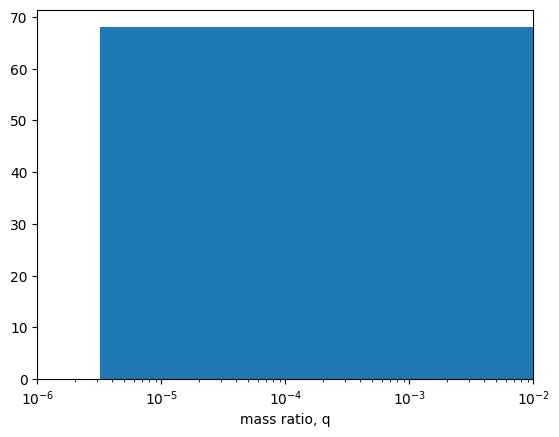

In [21]:
plt.hist(analyze_df['q'])
plt.xlabel('mass ratio, q')
plt.xscale('log')
plt.xlim([1e-6, 1e-2])
plt.show()

What did I even expect?

#### Actually useful analytics

How many events have LS, LO, and/or LX as the best model? 